# Early Product Success Prediction: Logistic Regression vs XGBoost

This notebook evaluates whether product success can be predicted using only the first 4 weeks of post-launch review
data.

We define product success as being in the top 10% of products within each category based on lifetime review count. We
construct product-level early features from the first 4 weeks of reviews, then compare a baseline Logistic Regression
model against an XGBoost classifier using the same train/test split.

In [1]:
# ==========================================
# Cell 2 — Imports and config
# ==========================================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SAMPLES_DIR = Path("samples")
FOUR_WEEKS_DAYS = 28
TOP_PCT = 0.10
TEST_SIZE = 0.20
RANDOM_SEED = 42
SUCCESS_LABEL_NAME = "success_top10"

In [2]:
# ==========================================
# Cell 3 — Helper functions
# ==========================================
def safe_numeric_vote(series: pd.Series) -> pd.Series:
    """
    Convert strings like '1,234' to numeric vote counts.
    Missing values become 0.
    """
    return (
        series.fillna("0")
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace({"": "0", "nan": "0", "None": "0"})
        .pipe(pd.to_numeric, errors="coerce")
        .fillna(0)
    )


def precision_at_k(y_true, y_score, k: int) -> float:
    """
    Precision among the top-k highest-scoring predictions.
    """
    if k <= 0:
        return np.nan
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    order = np.argsort(-y_score)
    top_k = y_true[order][:k]
    return float(np.mean(top_k))


def build_product_features_from_reviews(df_reviews: pd.DataFrame, category_name: str) -> pd.DataFrame:
    """
    Build product-level features using only the first 4 weeks of reviews
    after the first observed review for each product.
    """
    df = df_reviews.copy()

    # Numeric conversions
    df["unixReviewTime"] = pd.to_numeric(df["unixReviewTime"], errors="coerce")
    df["overall"] = pd.to_numeric(df["overall"], errors="coerce")

    if "vote" in df.columns:
        df["vote_num"] = safe_numeric_vote(df["vote"])
    else:
        df["vote_num"] = 0.0

    if "verified" in df.columns:
        df["verified_num"] = df["verified"].fillna(False).astype(int)
    else:
        df["verified_num"] = 0

    if "reviewText" in df.columns:
        df["review_text_len"] = df["reviewText"].fillna("").astype(str).str.len()
    else:
        df["review_text_len"] = 0

    if "summary" in df.columns:
        df["summary_len"] = df["summary"].fillna("").astype(str).str.len()
    else:
        df["summary_len"] = 0

    # Drop rows missing key identifiers or timestamps
    df = df.dropna(subset=["asin", "unixReviewTime", "overall"]).copy()

    # Sort within product
    df = df.sort_values(["asin", "unixReviewTime"]).reset_index(drop=True)

    # Relative time from first observed review
    first_time = df.groupby("asin")["unixReviewTime"].transform("min")
    df["days_since_first"] = (df["unixReviewTime"] - first_time) / (24 * 60 * 60)

    # Restrict to first 4 weeks
    df_4w = df[df["days_since_first"] <= FOUR_WEEKS_DAYS].copy()

    # Review sequence number within first 4 weeks
    df_4w["review_order"] = df_4w.groupby("asin").cumcount() + 1

    grp = df_4w.groupby("asin", sort=False)

    # Aggregate features
    features = grp.agg(
        n_reviews_4w=("overall", "size"),
        mean_rating_4w=("overall", "mean"),
        std_rating_4w=("overall", "std"),
        min_rating_4w=("overall", "min"),
        max_rating_4w=("overall", "max"),
        median_rating_4w=("overall", "median"),
        verified_ratio_4w=("verified_num", "mean"),
        mean_vote_4w=("vote_num", "mean"),
        sum_vote_4w=("vote_num", "sum"),
        mean_review_text_len_4w=("review_text_len", "mean"),
        mean_summary_len_4w=("summary_len", "mean"),
        first_4w_day_span=("days_since_first", "max"),
    ).reset_index()

    def rating_slope(sub: pd.DataFrame) -> float:
        x = sub["days_since_first"].to_numpy(dtype=float)
        y = sub["overall"].to_numpy(dtype=float)
        if len(x) < 2 or np.allclose(x, x[0]):
            return 0.0
        return float(np.polyfit(x, y, 1)[0])

    def review_velocity_slope(sub: pd.DataFrame) -> float:
        x = sub["days_since_first"].to_numpy(dtype=float)
        y = sub["review_order"].to_numpy(dtype=float)
        if len(x) < 2 or np.allclose(x, x[0]):
            return 0.0
        return float(np.polyfit(x, y, 1)[0])

    def late_minus_early_rating(sub: pd.DataFrame) -> float:
        sub = sub.sort_values("days_since_first")
        midpoint = FOUR_WEEKS_DAYS / 2

        early = sub.loc[sub["days_since_first"] <= midpoint, "overall"]
        late = sub.loc[sub["days_since_first"] > midpoint, "overall"]

        if len(early) == 0 or len(late) == 0:
            return 0.0

        return float(late.mean() - early.mean())

    slopes = grp.apply(
        lambda sub: pd.Series({
            "rating_slope_4w": rating_slope(sub),
            "review_velocity_slope_4w": review_velocity_slope(sub),
            "late_minus_early_rating_4w": late_minus_early_rating(sub),
        })
    ).reset_index()

    features = features.merge(slopes, on="asin", how="left")

    # Derived features
    features["reviews_per_day_4w"] = features["n_reviews_4w"] / FOUR_WEEKS_DAYS
    features["vote_per_review_4w"] = features["sum_vote_4w"] / features["n_reviews_4w"].clip(lower=1)
    features["category"] = category_name

    fill_zero_cols = [
        "std_rating_4w",
        "rating_slope_4w",
        "review_velocity_slope_4w",
        "late_minus_early_rating_4w",
    ]
    for col in fill_zero_cols:
        features[col] = features[col].fillna(0.0)

    return features


def build_success_labels(df_reviews: pd.DataFrame, top_pct: float = 0.10) -> pd.DataFrame:
    """
    Label the top X% of products within a category as successful,
    based on lifetime review count.
    """
    df = df_reviews.copy()
    df["overall"] = pd.to_numeric(df["overall"], errors="coerce")
    df["unixReviewTime"] = pd.to_numeric(df["unixReviewTime"], errors="coerce")
    df = df.dropna(subset=["asin", "unixReviewTime", "overall"]).copy()

    lifetime = (
        df.groupby("asin")
        .agg(
            total_reviews_lifetime=("overall", "size"),
            lifetime_mean_rating=("overall", "mean"),
            first_review_time=("unixReviewTime", "min"),
            last_review_time=("unixReviewTime", "max"),
        )
        .reset_index()
        .sort_values("total_reviews_lifetime", ascending=False)
        .reset_index(drop=True)
    )

    n_products = len(lifetime)
    n_top = max(1, int(np.ceil(top_pct * n_products)))

    lifetime[SUCCESS_LABEL_NAME] = 0
    lifetime.loc[:n_top - 1, SUCCESS_LABEL_NAME] = 1

    return lifetime


def evaluate_model(y_true, y_proba, threshold: float = 0.5) -> dict:
    """
    Compute a standard set of binary classification metrics.
    """
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    y_pred = (y_proba >= threshold).astype(int)

    k = int(np.sum(y_true))

    return {
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Average Precision": average_precision_score(y_true, y_proba),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision@K": precision_at_k(y_true, y_proba, k),
        "Test Positive Rate": float(np.mean(y_true)),
        "K used for Precision@K": int(k),
    }


def metrics_dict_to_df(metrics_dict: dict, model_name: str) -> pd.DataFrame:
    """
    Convert metrics dict to a display-friendly dataframe.
    """
    return pd.DataFrame({
        "metric": list(metrics_dict.keys()),
        model_name: list(metrics_dict.values())
    })


def compute_category_metrics(test_df: pd.DataFrame, category_col: str = "category") -> pd.DataFrame:
    """
    Compute evaluation metrics by category.
    Expects columns: category, y_true, y_proba, y_pred
    """
    rows = []

    for category, sub in test_df.groupby(category_col):
        if sub["y_true"].nunique() < 2:
            continue

        rows.append({
            "category": category,
            "n_products": len(sub),
            "positive_rate": sub["y_true"].mean(),
            "roc_auc": roc_auc_score(sub["y_true"], sub["y_proba"]),
            "avg_precision": average_precision_score(sub["y_true"], sub["y_proba"]),
            "precision": precision_score(sub["y_true"], sub["y_pred"], zero_division=0),
            "recall": recall_score(sub["y_true"], sub["y_pred"], zero_division=0),
            "f1": f1_score(sub["y_true"], sub["y_pred"], zero_division=0),
        })

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)

In [3]:
# ==========================================
# Cell 4 — Build the product-level dataset
# ==========================================
all_product_rows = []

category_dirs = sorted([d for d in SAMPLES_DIR.iterdir() if d.is_dir()])

print(f"Found {len(category_dirs)} category folders")

for category_dir in category_dirs:
    file_path = category_dir / "sample_reviews.parquet"
    category_name = category_dir.name

    if not file_path.exists():
        print(f"Skipping {category_name}: sample_reviews.parquet not found")
        continue

    print(f"Loading category: {category_name}")

    needed_cols = [
        "asin",
        "overall",
        "unixReviewTime",
        "reviewText",
        "summary",
        "verified",
        "vote",
    ]

    df_reviews = pd.read_parquet(file_path, columns=needed_cols)

    features = build_product_features_from_reviews(df_reviews, category_name=category_name)
    labels = build_success_labels(df_reviews, top_pct=TOP_PCT)

    category_product_df = features.merge(labels, on="asin", how="inner")
    all_product_rows.append(category_product_df)

product_df = pd.concat(all_product_rows, ignore_index=True)

print("Final product-level dataset shape:", product_df.shape)
product_df.head()

,asin,n_reviews_4w,mean_rating_4w,std_rating_4w,min_rating_4w,max_rating_4w,median_rating_4w,verified_ratio_4w,mean_vote_4w,sum_vote_4w,...,review_velocity_slope_4w,late_minus_early_rating_4w,reviews_per_day_4w,vote_per_review_4w,category,total_reviews_lifetime,lifetime_mean_rating,first_review_time,last_review_time,success_top10
0,5120053351,6,5.0,0.00000,5.0,5.0,5.0,0.50,11.166667,67,...,0.154286,0.000000,0.214286,11.166667,"Clothing, Shoes and Jewelry",52,4.000000,1453507200,1520294400,0
1,5120053890,4,4.5,0.57735,4.0,5.0,4.5,0.25,1.500000,6,...,0.140397,-0.666667,0.142857,1.500000,"Clothing, Shoes and Jewelry",34,4.588235,1465516800,1522713600,0
2,B00001W0GC,1,5.0,0.00000,5.0,5.0,5.0,1.00,0.000000,0,...,0.000000,0.000000,0.035714,0.000000,"Clothing, Shoes and Jewelry",68,3.588235,1257897600,1513728000,0
3,B000074RL3,1,5.0,0.00000,5.0,5.0,5.0,0.00,28.000000,28,...,0.000000,0.000000,0.035714,28.000000,"Clothing, Shoes and Jewelry",29,4.517241,1112313600,1523664000,0
4,B0000865II,1,4.0,0.00000,4.0,4.0,4.0,1.00,0.000000,0,...,0.000000,0.000000,0.035714,0.000000,"Clothing, Shoes and Jewelry",396,4.063131,1168819200,1526515200,1


In [4]:
# ==========================================
# Cell 5 — Sanity checks
# ==========================================
print("Overall shape:", product_df.shape)
print("\nColumns:")
print(product_df.columns.tolist())

print("\nMissing values (top 20):")
display(product_df.isna().sum().sort_values(ascending=False).head(20))

label_summary = (
    product_df.groupby("category")[SUCCESS_LABEL_NAME]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "n_products", "sum": "n_success", "mean": "success_rate"})
    .reset_index()
)

print("\nSuccess rate by category:")
display(label_summary)

print("\nPreview:")
display(product_df.head())

print("\nSelected numeric summary:")
display(
    product_df[
        [
            "n_reviews_4w",
            "mean_rating_4w",
            "std_rating_4w",
            "reviews_per_day_4w",
            "rating_slope_4w",
            "review_velocity_slope_4w",
            "total_reviews_lifetime",
        ]
    ].describe()
)

,n_reviews_4w,mean_rating_4w,std_rating_4w,reviews_per_day_4w,rating_slope_4w,review_velocity_slope_4w,total_reviews_lifetime
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.437260,4.399592,0.266979,0.087045,-0.000563,0.079813,76.427500
std,3.694836,0.913048,0.544864,0.131958,0.150539,0.187969,168.048333
min,1.000000,1.000000,0.000000,0.035714,-4.000000,0.000000,20.000000
25%,1.000000,4.000000,0.000000,0.035714,0.000000,0.000000,26.000000
50%,1.000000,5.000000,0.000000,0.035714,0.000000,0.000000,39.000000
75%,2.000000,5.000000,0.377964,0.071429,0.000000,0.083333,70.000000
max,178.000000,5.000000,2.828427,6.357143,4.000000,6.335987,8067.000000


In [5]:
# ==========================================
# Cell 6 — Feature selection and train/test split
# ==========================================
feature_cols_num = [
    "n_reviews_4w",
    "mean_rating_4w",
    "std_rating_4w",
    "min_rating_4w",
    "max_rating_4w",
    "median_rating_4w",
    "verified_ratio_4w",
    "mean_vote_4w",
    "sum_vote_4w",
    "mean_review_text_len_4w",
    "mean_summary_len_4w",
    "first_4w_day_span",
    "rating_slope_4w",
    "review_velocity_slope_4w",
    "late_minus_early_rating_4w",
    "reviews_per_day_4w",
    "vote_per_review_4w",
]

feature_cols_cat = ["category"]
target_col = SUCCESS_LABEL_NAME

model_df = product_df[["asin", target_col] + feature_cols_num + feature_cols_cat].copy()

X = model_df[feature_cols_num + feature_cols_cat]
y = model_df[target_col]

X_train, X_test, y_train, y_test, asin_train, asin_test = train_test_split(
    X,
    y,
    model_df["asin"],
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train shape: (40000, 18)
Test shape: (10000, 18)
Train positive rate: 0.1
Test positive rate: 0.1


In [6]:
# ==========================================
# Cell 7 — Logistic Regression preprocessing and pipeline
# ==========================================
logreg_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            feature_cols_num,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            feature_cols_cat,
        ),
    ]
)

logreg_pipeline = Pipeline(steps=[
    ("preprocess", logreg_preprocess),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    )),
])

logreg_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['n_reviews_4w',
                                                   'mean_rating_4w',
                                                   'std_rating_4w',
                                                   'min_rating_4w',
                                                   'max_rating_4w',
                                                   'median_rating_4w',
                                                   'verified_ratio_4w',
                                                   'mean_vote_4w',
                                                   'sum_vote_4w',
                                                   'mean_review_text_len_4w',
                                                   'mean_summary_l...
                                                   'first_4w_day_span',
                                                   'rating_slope_4w',
                                                   'review_velocity_slope_4w',
                                                   'late_minus_early_rating_4w',
                                                   'reviews_per_day_4w',
                                                   'vote_per_review_4w']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['category'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [7]:
# ==========================================
# Cell 8 — Train Logistic Regression
# ==========================================
logreg_pipeline.fit(X_train, y_train)

y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]
y_pred_logreg = (y_proba_logreg >= 0.5).astype(int)

metrics_logreg = evaluate_model(y_test, y_proba_logreg, threshold=0.5)
metrics_logreg_df = metrics_dict_to_df(metrics_logreg, "Logistic Regression")

display(metrics_logreg_df)

,metric,Logistic Regression
0,ROC-AUC,0.638440
1,Average Precision,0.214516
2,Precision,0.187528
3,Recall,0.424000
4,F1,0.260043
5,Precision@K,0.257000
6,Test Positive Rate,0.100000
7,K used for Precision@K,1000.000000


In [8]:
# ==========================================
# Cell 9 — XGBoost preprocessing
# ==========================================
xgb_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            feature_cols_num,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            feature_cols_cat,
        ),
    ]
)

X_train_xgb = xgb_preprocess.fit_transform(X_train)
X_test_xgb = xgb_preprocess.transform(X_test)

print("Processed X_train shape:", X_train_xgb.shape)
print("Processed X_test shape:", X_test_xgb.shape)

Processed X_train shape: (40000, 22)
Processed X_test shape: (10000, 22)


In [9]:
# ==========================================
# Cell 10 — Train XGBoost
# ==========================================
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / max(pos_count, 1)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=RANDOM_SEED,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
)

xgb_model.fit(X_train_xgb, y_train)

y_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

metrics_xgb = evaluate_model(y_test, y_proba_xgb, threshold=0.5)
metrics_xgb_df = metrics_dict_to_df(metrics_xgb, "XGBoost")

display(metrics_xgb_df)

,metric,XGBoost
0,ROC-AUC,0.678982
1,Average Precision,0.249905
2,Precision,0.200502
3,Recall,0.479000
4,F1,0.282679
5,Precision@K,0.287000
6,Test Positive Rate,0.100000
7,K used for Precision@K,1000.000000


In [10]:
# ==========================================
# Cell 11 — Metrics comparison table
# ==========================================
metric_order = list(metrics_logreg.keys())

comparison_df = pd.DataFrame({
    "metric": metric_order,
    "Logistic Regression": [metrics_logreg[m] for m in metric_order],
    "XGBoost": [metrics_xgb[m] for m in metric_order],
})

comparison_df["XGB_minus_LogReg"] = comparison_df["XGBoost"] - comparison_df["Logistic Regression"]

display(comparison_df)

,metric,Logistic Regression,XGBoost,XGB_minus_LogReg
0,ROC-AUC,0.638440,0.678982,0.040542
1,Average Precision,0.214516,0.249905,0.035389
2,Precision,0.187528,0.200502,0.012975
3,Recall,0.424000,0.479000,0.055000
4,F1,0.260043,0.282679,0.022636
5,Precision@K,0.257000,0.287000,0.030000
6,Test Positive Rate,0.100000,0.100000,0.000000
7,K used for Precision@K,1000.000000,1000.000000,0.000000


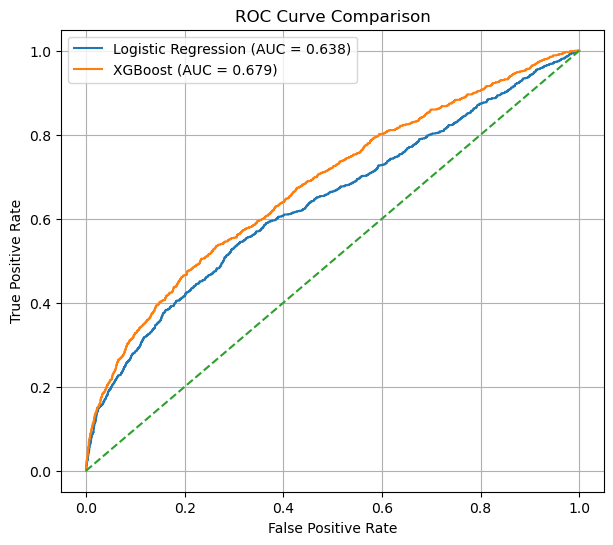

In [11]:
# ==========================================
# Cell 12 — ROC curve comparison
# ==========================================
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(7, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression (AUC = {metrics_logreg['ROC-AUC']:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {metrics_xgb['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

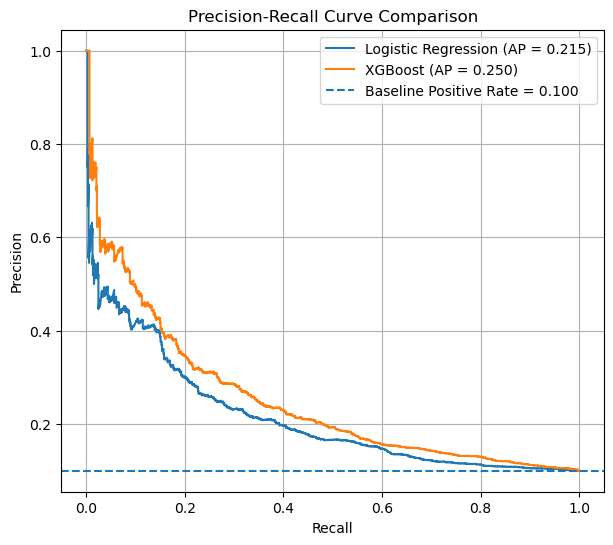

In [12]:
# ==========================================
# Cell 13 — Precision-recall curve comparison
# ==========================================
precision_lr_curve, recall_lr_curve, _ = precision_recall_curve(y_test, y_proba_logreg)
precision_xgb_curve, recall_xgb_curve, _ = precision_recall_curve(y_test, y_proba_xgb)

baseline_rate = y_test.mean()

plt.figure(figsize=(7, 6))
plt.plot(recall_lr_curve, precision_lr_curve, label=f"Logistic Regression (AP = {metrics_logreg['Average Precision']:.3f})")
plt.plot(recall_xgb_curve, precision_xgb_curve, label=f"XGBoost (AP = {metrics_xgb['Average Precision']:.3f})")
plt.axhline(baseline_rate, linestyle="--", label=f"Baseline Positive Rate = {baseline_rate:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

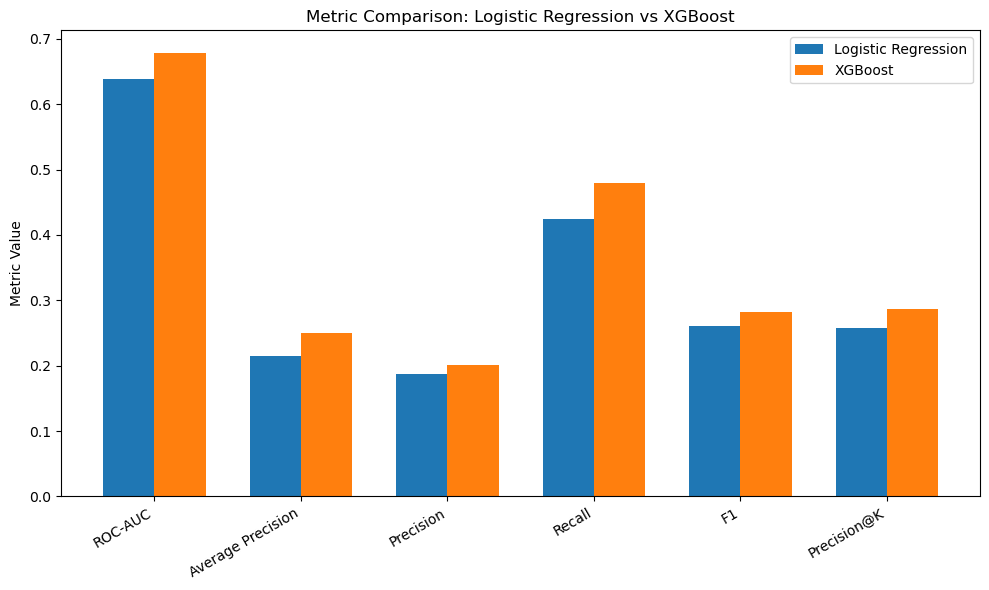

In [13]:
# ==========================================
# Cell 14 — Metric bar chart comparison
# ==========================================
plot_metrics = ["ROC-AUC", "Average Precision", "Precision", "Recall", "F1", "Precision@K"]
plot_df = comparison_df[comparison_df["metric"].isin(plot_metrics)].copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, plot_df["Logistic Regression"], width, label="Logistic Regression")
plt.bar(x + width / 2, plot_df["XGBoost"], width, label="XGBoost")

plt.xticks(x, plot_df["metric"], rotation=30, ha="right")
plt.ylabel("Metric Value")
plt.title("Metric Comparison: Logistic Regression vs XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# ==========================================
# Cell 15 — Confusion matrices
# ==========================================
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

cm_logreg_df = pd.DataFrame(
    cm_logreg,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

cm_xgb_df = pd.DataFrame(
    cm_xgb,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("Logistic Regression Confusion Matrix")
display(cm_logreg_df)

,Predicted 0,Predicted 1
Actual 0,7163,1837
Actual 1,576,424


In [15]:
print("XGBoost Confusion Matrix")
display(cm_xgb_df)

,Predicted 0,Predicted 1
Actual 0,7090,1910
Actual 1,521,479


In [16]:
# ==========================================
# Cell 16 — Logistic regression coefficients
# ==========================================
logreg_feature_names = logreg_pipeline.named_steps["preprocess"].get_feature_names_out()
logreg_coefs = logreg_pipeline.named_steps["model"].coef_[0]

logreg_coef_df = pd.DataFrame({
    "feature": logreg_feature_names,
    "coefficient": logreg_coefs,
    "abs_coefficient": np.abs(logreg_coefs),
}).sort_values("abs_coefficient", ascending=False)

print("Top positive/negative logistic regression coefficients")
display(logreg_coef_df.head(20))

,feature,coefficient,abs_coefficient
8,num__sum_vote_4w,0.484358,0.484358
4,num__max_rating_4w,-0.409305,0.409305
1,num__mean_rating_4w,0.354456,0.354456
7,num__mean_vote_4w,0.260252,0.260252
16,num__vote_per_review_4w,0.260252,0.260252
18,cat__category_Electronics,-0.188506,0.188506
9,num__mean_review_text_len_4w,-0.159299,0.159299
5,num__median_rating_4w,0.131229,0.131229
2,num__std_rating_4w,0.106125,0.106125
3,num__min_rating_4w,-0.092449,0.092449


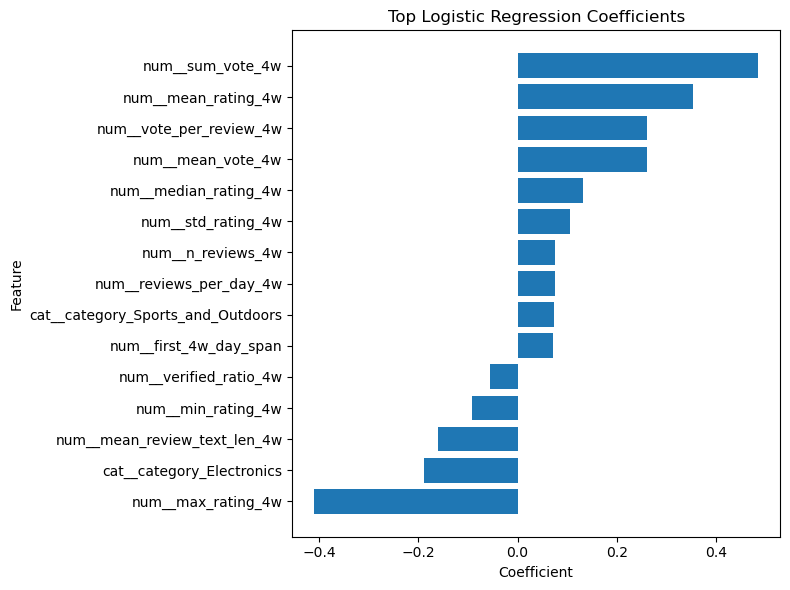

In [17]:
# ==========================================
# Cell 17 — Plot top logistic regression coefficients
# ==========================================
top_n = 15
top_coef_df = logreg_coef_df.head(top_n).sort_values("coefficient")

plt.figure(figsize=(8, 6))
plt.barh(top_coef_df["feature"], top_coef_df["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

In [18]:
# ==========================================
# Cell 18 — XGBoost feature importances
# ==========================================
xgb_feature_names = xgb_preprocess.get_feature_names_out()
xgb_importances = xgb_model.feature_importances_

xgb_importance_df = pd.DataFrame({
    "feature": xgb_feature_names,
    "importance": xgb_importances,
}).sort_values("importance", ascending=False)

display(xgb_importance_df.head(20))

,feature,importance
8,num__sum_vote_4w,0.165591
16,num__vote_per_review_4w,0.085231
15,num__reviews_per_day_4w,0.058714
9,num__mean_review_text_len_4w,0.051806
0,num__n_reviews_4w,0.048575
11,num__first_4w_day_span,0.047959
6,num__verified_ratio_4w,0.045140
7,num__mean_vote_4w,0.040658
18,cat__category_Electronics,0.040111
5,num__median_rating_4w,0.038721


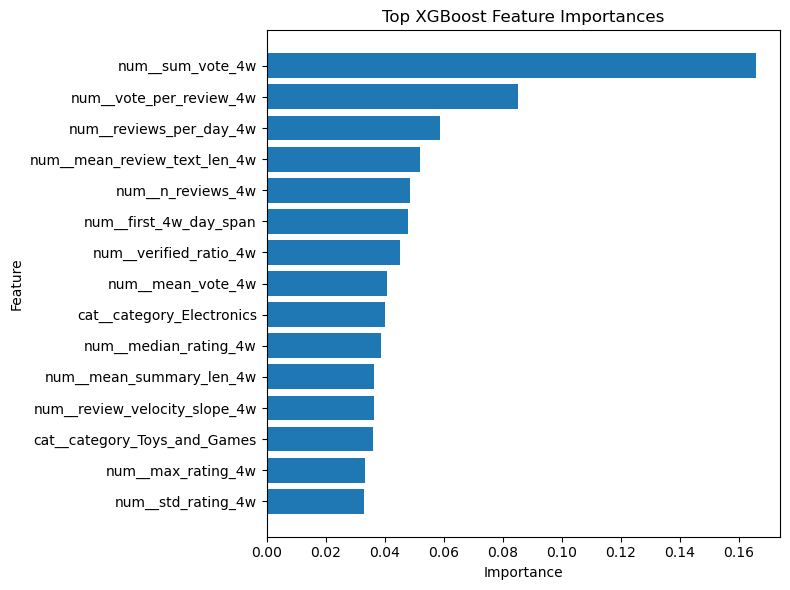

In [19]:
# ==========================================
# Cell 19 — Plot top XGBoost feature importances
# ==========================================
top_n = 15
top_importance_df = xgb_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_importance_df["feature"], top_importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top XGBoost Feature Importances")
plt.tight_layout()
plt.show()

In [20]:
# ==========================================
# Cell 20 — Category-level performance breakdown
# ==========================================
test_results_logreg = X_test.copy()
test_results_logreg["asin"] = asin_test.values
test_results_logreg["y_true"] = y_test.values
test_results_logreg["y_proba"] = y_proba_logreg
test_results_logreg["y_pred"] = y_pred_logreg

test_results_xgb = X_test.copy()
test_results_xgb["asin"] = asin_test.values
test_results_xgb["y_true"] = y_test.values
test_results_xgb["y_proba"] = y_proba_xgb
test_results_xgb["y_pred"] = y_pred_xgb

category_metrics_logreg = compute_category_metrics(test_results_logreg)
category_metrics_xgb = compute_category_metrics(test_results_xgb)

print("Category-level metrics — Logistic Regression")
display(category_metrics_logreg)

,category,n_products,positive_rate,roc_auc,avg_precision,precision,recall,f1
0,Tools and Home Improvement,1971,0.097920,0.656096,0.228969,0.209790,0.466321,0.289389
1,Electronics,2024,0.101285,0.651604,0.227369,0.198529,0.395122,0.264274
2,"Clothing, Shoes and Jewelry",2013,0.104322,0.647152,0.271963,0.202151,0.447619,0.278519
3,Sports_and_Outdoors,2051,0.095076,0.643756,0.203557,0.165692,0.435897,0.240113
4,Toys_and_Games,1941,0.101494,0.621030,0.208542,0.165919,0.375635,0.230171


In [21]:
print("XGBoost Confusion Matrix")
display(cm_xgb_df)

,Predicted 0,Predicted 1
Actual 0,7090,1910
Actual 1,521,479


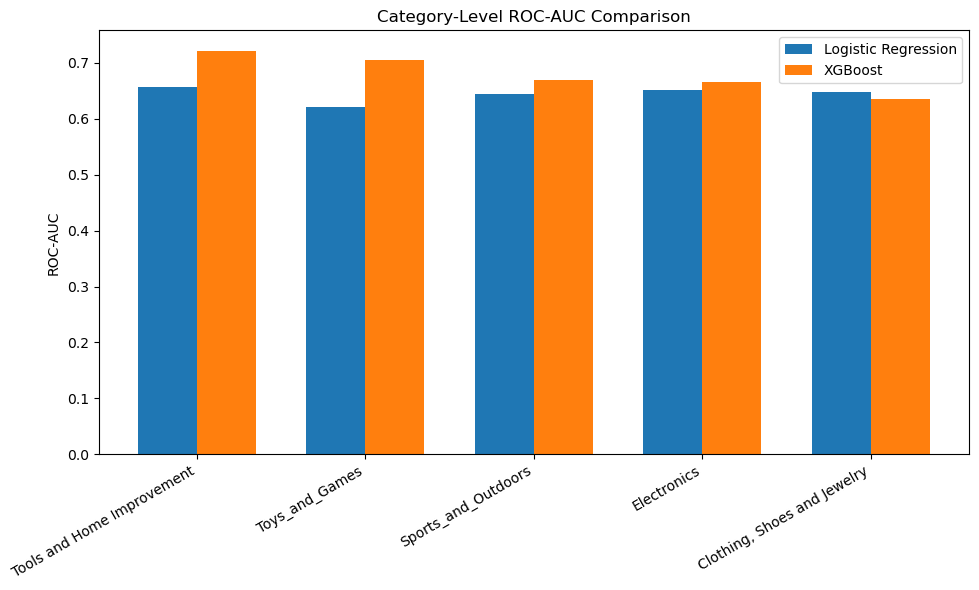

In [22]:
# ==========================================
# Cell 21 — Side-by-side category ROC-AUC comparison
# ==========================================
if not category_metrics_logreg.empty and not category_metrics_xgb.empty:
    category_compare = category_metrics_logreg[["category", "roc_auc"]].merge(
        category_metrics_xgb[["category", "roc_auc"]],
        on="category",
        suffixes=("_logreg", "_xgb")
    )

    category_compare = category_compare.sort_values("roc_auc_xgb", ascending=False).reset_index(drop=True)
    display(category_compare)

    x = np.arange(len(category_compare))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width / 2, category_compare["roc_auc_logreg"], width, label="Logistic Regression")
    plt.bar(x + width / 2, category_compare["roc_auc_xgb"], width, label="XGBoost")

    plt.xticks(x, category_compare["category"], rotation=30, ha="right")
    plt.ylabel("ROC-AUC")
    plt.title("Category-Level ROC-AUC Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Not enough category-level class variation to compute both sets of ROC-AUC values.")

In [23]:
# ==========================================
# Cell 22 — Final summary table for report use
# ==========================================
report_metrics = ["ROC-AUC", "Average Precision", "Precision", "Recall", "F1", "Precision@K"]

report_table = comparison_df[comparison_df["metric"].isin(report_metrics)].copy()
report_table["Improvement (%)"] = (
    (report_table["XGB_minus_LogReg"] / report_table["Logistic Regression"]) * 100
).replace([np.inf, -np.inf], np.nan)

display(report_table)

,metric,Logistic Regression,XGBoost,XGB_minus_LogReg,Improvement (%)
0,ROC-AUC,0.638440,0.678982,0.040542,6.350103
1,Average Precision,0.214516,0.249905,0.035389,16.497362
2,Precision,0.187528,0.200502,0.012975,6.918798
3,Recall,0.424000,0.479000,0.055000,12.971698
4,F1,0.260043,0.282679,0.022636,8.704841
5,Precision@K,0.257000,0.287000,0.030000,11.673152


## Summary

Using only the first 4 weeks of post-launch review data, both models achieved better-than-random performance in
predicting which products would eventually fall into the top 10% of their category.

XGBoost outperformed Logistic Regression across all major metrics, indicating that nonlinear relationships and feature
interactions improve early product success prediction. The strongest gains appeared in ROC-AUC, recall, and Precision@K,
suggesting that XGBoost is especially better at identifying and ranking promising products early.

These results support the conclusion that early product success is partially predictable, though performance remains
moderate and likely limited by the current feature set. The next major improvement is to add NLP-derived features such
as sentiment and review text signals.

In [24]:
# ==========================================
# Q2 — Correlation of early indicators with success
# ==========================================
corr_df = product_df[feature_cols_num + [target_col]].corr(numeric_only=True)

target_corr_df = (
    corr_df[[target_col]]
    .drop(index=target_col)
    .rename(columns={target_col: "correlation_with_success"})
    .sort_values("correlation_with_success", ascending=False)
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(target_corr_df)

,feature,correlation_with_success
0,sum_vote_4w,0.149646
1,mean_vote_4w,0.128280
2,vote_per_review_4w,0.128280
3,n_reviews_4w,0.088263
4,reviews_per_day_4w,0.088263
5,review_velocity_slope_4w,0.060348
6,first_4w_day_span,0.053461
7,mean_review_text_len_4w,0.040094
8,std_rating_4w,0.027445
9,max_rating_4w,0.011351


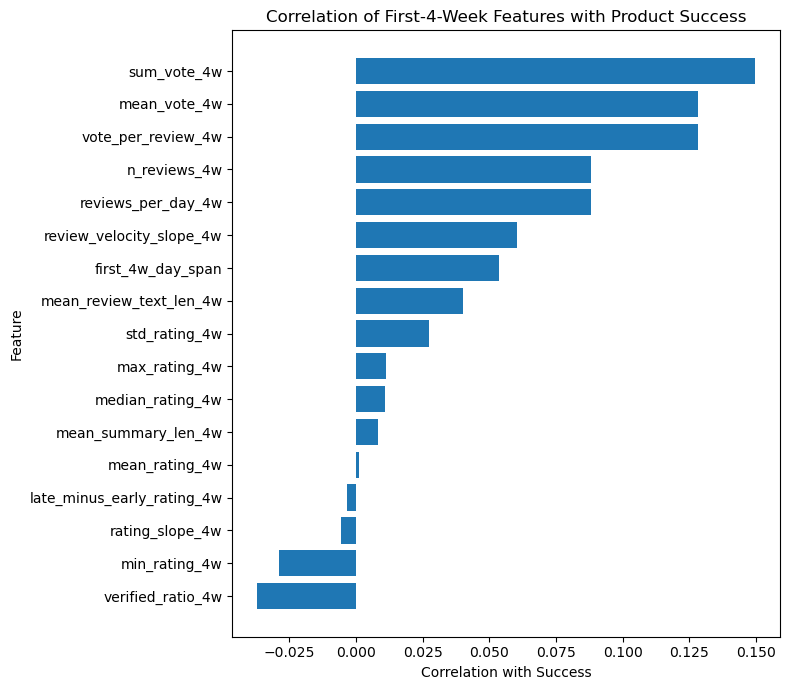

In [25]:
# ==========================================
# Q2 — Plot feature correlations with success
# ==========================================
plot_corr_df = target_corr_df.sort_values("correlation_with_success")

plt.figure(figsize=(8, 7))
plt.barh(plot_corr_df["feature"], plot_corr_df["correlation_with_success"])
plt.xlabel("Correlation with Success")
plt.ylabel("Feature")
plt.title("Correlation of First-4-Week Features with Product Success")
plt.tight_layout()
plt.show()

In [26]:
# ==========================================
# Q3 — Merge category ROC-AUC by model
# ==========================================
category_auc_compare = category_metrics_logreg[["category", "roc_auc"]].merge(
    category_metrics_xgb[["category", "roc_auc"]],
    on="category",
    suffixes=("_logreg", "_xgb")
)

category_auc_compare = category_auc_compare.sort_values("roc_auc_xgb", ascending=False).reset_index(drop=True)

display(category_auc_compare)

,category,roc_auc_logreg,roc_auc_xgb
0,Tools and Home Improvement,0.656096,0.722112
1,Toys_and_Games,0.621030,0.705259
2,Sports_and_Outdoors,0.643756,0.670254
3,Electronics,0.651604,0.665109
4,"Clothing, Shoes and Jewelry",0.647152,0.635985


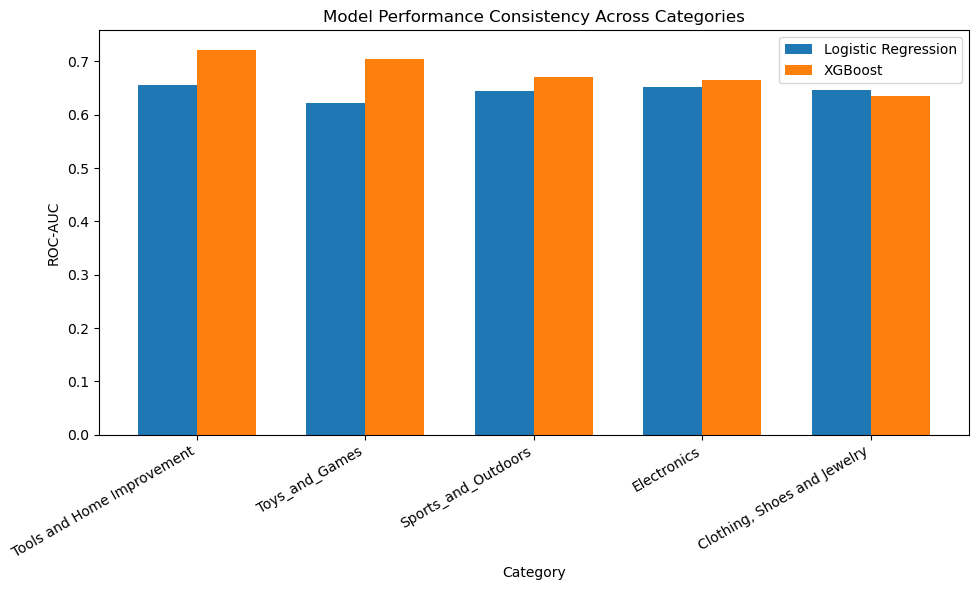

In [27]:
# ==========================================
# Q3 — ROC-AUC by category for both models
# ==========================================
x = np.arange(len(category_auc_compare))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, category_auc_compare["roc_auc_logreg"], width, label="Logistic Regression")
plt.bar(x + width / 2, category_auc_compare["roc_auc_xgb"], width, label="XGBoost")

plt.xticks(x, category_auc_compare["category"], rotation=30, ha="right")
plt.ylabel("ROC-AUC")
plt.xlabel("Category")
plt.title("Model Performance Consistency Across Categories")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# ==========================================
# Q3 — Summary stats for consistency across categories
# ==========================================
consistency_summary = pd.DataFrame({
    "statistic": ["mean", "std", "min", "max", "range"],
    "Logistic Regression": [
        category_auc_compare["roc_auc_logreg"].mean(),
        category_auc_compare["roc_auc_logreg"].std(),
        category_auc_compare["roc_auc_logreg"].min(),
        category_auc_compare["roc_auc_logreg"].max(),
        category_auc_compare["roc_auc_logreg"].max() - category_auc_compare["roc_auc_logreg"].min(),
    ],
    "XGBoost": [
        category_auc_compare["roc_auc_xgb"].mean(),
        category_auc_compare["roc_auc_xgb"].std(),
        category_auc_compare["roc_auc_xgb"].min(),
        category_auc_compare["roc_auc_xgb"].max(),
        category_auc_compare["roc_auc_xgb"].max() - category_auc_compare["roc_auc_xgb"].min(),
    ],
})

display(consistency_summary)

,statistic,Logistic Regression,XGBoost
0,mean,0.643927,0.679744
1,std,0.013617,0.034151
2,min,0.621030,0.635985
3,max,0.656096,0.722112
4,range,0.035066,0.086127


In [29]:
# ==========================================
# Q3 — Best and worst category by model
# ==========================================
best_logreg = category_auc_compare.loc[category_auc_compare["roc_auc_logreg"].idxmax()]
worst_logreg = category_auc_compare.loc[category_auc_compare["roc_auc_logreg"].idxmin()]

best_xgb = category_auc_compare.loc[category_auc_compare["roc_auc_xgb"].idxmax()]
worst_xgb = category_auc_compare.loc[category_auc_compare["roc_auc_xgb"].idxmin()]

summary_rows = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "best_category": best_logreg["category"],
        "best_auc": best_logreg["roc_auc_logreg"],
        "worst_category": worst_logreg["category"],
        "worst_auc": worst_logreg["roc_auc_logreg"],
    },
    {
        "model": "XGBoost",
        "best_category": best_xgb["category"],
        "best_auc": best_xgb["roc_auc_xgb"],
        "worst_category": worst_xgb["category"],
        "worst_auc": worst_xgb["roc_auc_xgb"],
    }
])

display(summary_rows)

,model,best_category,best_auc,worst_category,worst_auc
0,Logistic Regression,Tools and Home Improvement,0.656096,Toys_and_Games,0.621030
1,XGBoost,Tools and Home Improvement,0.722112,"Clothing, Shoes and Jewelry",0.635985
